In [34]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

clinical_gex = pl.read_csv(f"../dataset/created/clinical_gex.csv")
clinical_gex

patientID,sex,age,AJCC_stage,M_stage,LDH,PFS_month,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment,source,pfs_label,cobimetinib,dabrafenib,trametinib,vemurafenib,C195W,K601I,MND,R558Q,V600E,V600K,V600R,sample_id,source_right,pfs_label_right,TYRP1,RPS4Y1,KRT6A,SERPINA3,KRT14,KRT1,DCT,XIST,S100A7,KRT5,KRT6B,…,CMBL,PFKP,TWIST1,SNORA62,TUBA4A,LDLR,TNFRSF11B,CNIH3,AFF3,IL1RAP,DHRS2,SAT1,MMP10,FHDC1,HPS5,MARCO,ANXA5,FZD9,SPRR2A,OLFML3,COL18A1,NKX2-5,RMRP,HOXA5,NID1,RPL26,CADM4,RPS18,SNORA9,CIITA,RASIP1,DUSP5,MYO10,CD7,LRRN4CL,HOXA10,SSB
str,str,i64,str,str,str,f64,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""YR_3053""","""male""",26,"""IV""","""M1B""","""elevated""",2.9,null,"""no""","""no""","""Yan et al.""",0,0,0,0,1,0,0,0,0,1,0,0,"""03660555B""","""Yan et al.""",0,5.51083,9.960501,3.509668,13.339556,3.540016,3.275452,7.971416,5.710717,3.987287,3.360387,3.997754,…,5.634377,6.731175,5.889609,5.379414,5.232139,6.23204,4.319166,5.532268,5.291643,6.62422,4.862721,9.092187,4.395211,5.80194,6.165165,5.653768,10.386252,5.768099,4.400383,7.294795,6.85764,4.262224,8.013022,5.823376,6.418434,10.336403,6.464137,11.447061,3.536429,4.708992,5.900719,7.30317,8.166737,5.164095,5.498254,6.040796,7.200556
"""YR_3708""","""female""",58,"""IV""","""M1A""","""normal""",13.2,null,"""no""","""no""","""Yan et al.""",2,0,0,0,1,0,0,0,0,1,0,0,"""03660598B""","""Yan et al.""",2,5.381057,10.746502,3.528969,8.02604,4.030594,4.105297,7.948809,4.935802,3.943303,3.840459,3.993934,…,5.584502,6.26575,5.83032,4.193377,5.010662,5.806783,4.034853,6.285202,5.214611,5.75183,4.843877,8.657526,4.391645,5.332514,6.595678,4.761549,11.227422,5.772585,4.400383,5.823766,7.352494,4.176478,8.397533,5.749767,5.389069,10.713004,5.502746,12.375512,4.210186,4.162135,5.853875,6.107506,8.356113,5.063898,5.672238,5.430335,7.089221
"""YR_3705""","""male""",45,"""IV""","""M1A""","""normal""",17.4,null,"""no""","""no""","""Yan et al.""",2,0,0,0,1,0,0,0,0,1,0,0,"""03660602B""","""Yan et al.""",2,5.42637,7.074704,3.526899,9.990084,3.52744,3.282247,6.426219,8.643733,3.936513,3.505735,4.005092,…,5.60725,7.154908,5.829134,5.715625,5.291147,5.948483,5.096029,5.540155,5.201738,6.2461,4.781539,10.593236,4.390825,5.41408,6.58062,4.850648,9.935467,5.758758,4.407717,7.259082,6.432412,4.175607,6.577444,5.737585,4.850486,10.679055,5.45328,11.140229,4.094438,6.578668,5.831115,6.95046,5.997652,5.216438,5.482354,5.419554,7.595413
"""YR_1106""","""male""",48,"""IIIC""",null,"""normal""",1.4,null,"""no""","""no""","""Yan et al.""",0,1,0,0,1,0,0,0,0,1,0,0,"""04240076F""","""Yan et al.""",0,5.441232,5.058232,3.522887,6.093551,4.06148,5.712626,7.194271,8.217577,4.0445,4.262991,3.994574,…,5.62414,6.652326,5.834738,5.284366,5.290178,6.343789,4.254652,5.143464,5.168968,5.521475,4.782108,9.749056,4.388087,5.321013,6.312449,4.967701,10.034415,5.759508,4.400383,6.888973,8.04498,4.175607,7.184806,5.749157,6.187127,10.227309,5.405615,10.968125,4.094872,5.426855,5.91499,6.117476,6.095347,5.117187,5.488947,5.946902,6.76686
"""YR_1110""","""male""",33,"""IV""","""M1C""","""normal""",1.4,null,"""no""","""no""","""Yan et al.""",0,1,0,0,1,0,0,0,0,1,0,0,"""04240106F""","""Yan et al.""",0,5.541315,9.913488,3.500742,6.107622,3.533553,3.276241,11.683398,3.929127,3.936513,3.351618,3.986339,…,5.620168,5.748576,5.817551,5.430763,4.955551,5.69262,4.035387,5.15494,5.846369,5.674766,4.869859,10.719777,4.386126,5.73927,7.576451,5.400574,11.730204,5.842538,4.400383,5.794726,7.184871,4.175607,8.186643,6.038834,4.969885,10.714758,6.09405,12.277055,5.949107,3.977881,5.899574,5.994677,8.237265,5.050927,5.640694,5.333841,6.600348
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""HL_Shi-35""","""male""

## 1. Dataset Overview

In [35]:
# Identify clinical vs gene expression columns
# Clinical columns are the first 25 (up to pfs_label_right), GEX starts after
CLINICAL_COLS = ["patientID", "sex", "age", "AJCC_stage", "M_stage", "LDH",
                 "brain_metastasis", "immunotherapy_treatment", "pre_MAPKi_treatment",
                 "source", "pfs_label", "cobimetinib", "dabrafenib", "trametinib",
                 "vemurafenib", "C195W", "K601I", "MND", "R558Q", "V600E", "V600K",
                 "V600R", "sample_id", "source_right", "pfs_label_right", "PFS_month"]
GEX_COLS = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]

print(f"Shape: {clinical_gex.shape}")
print(f"Clinical columns : {len(CLINICAL_COLS)}")
print(f"Gene expression columns: {len(GEX_COLS)}")
print(f"\nDtypes:\n{clinical_gex.dtypes}")
print(f"\nFirst GEX genes: {GEX_COLS[:10]}")
print(f"Last  GEX genes: {GEX_COLS[-10:]}")

Shape: (137, 1026)
Clinical columns : 26
Gene expression columns: 1000

Dtypes:
[String, String, Int64, String, String, String, Float64, String, String, String, String, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, String, String, Int64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Floa

In [36]:
from sklearn.decomposition import PCA

X = clinical_gex[GEX_COLS]
y = clinical_gex['pfs_label']

pca = PCA(n_components=3)
X_pca = pca.fit_transform(clinical_gex[GEX_COLS])
print(X_pca[:2])


[[ 2.99958267 -5.98497349 -7.4963682 ]
 [-4.22999297 -2.36770689  1.11056846]]


In [37]:
print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

Explained variance: [0.11433885 0.07799011 0.06275448]
Cumulative: [0.11433885 0.19232895 0.25508343]


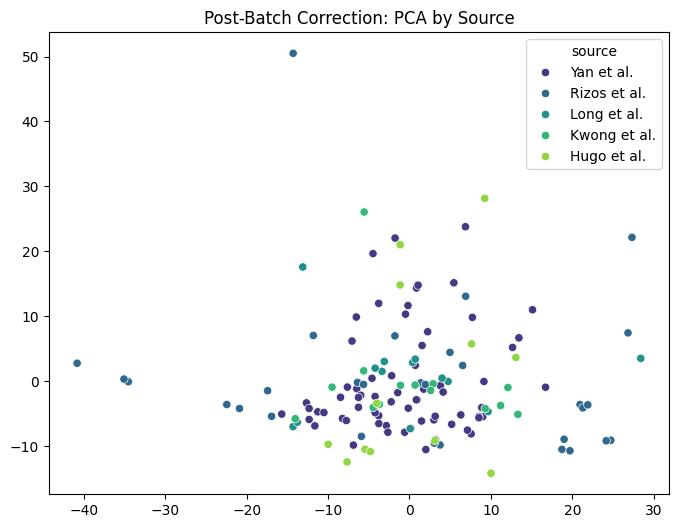

In [47]:
import seaborn as sns

# Plot PC1 vs PC2 colored by Source
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clinical_gex['source'], palette='viridis')
plt.title("Post-Batch Correction: PCA by Source")
plt.show()

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


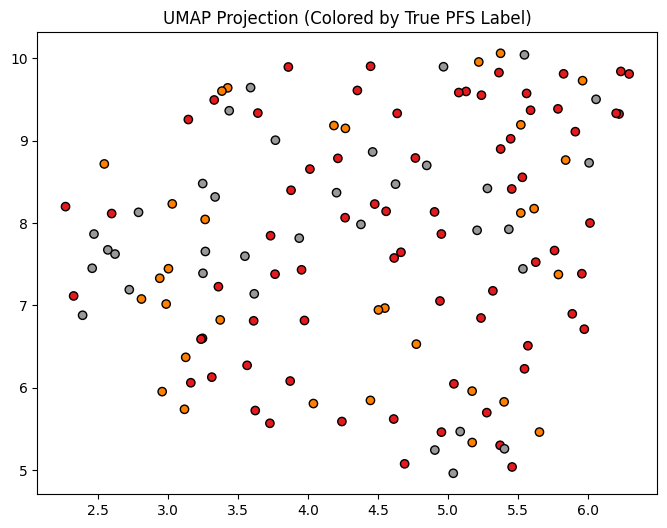

In [51]:
import umap

# Use the same top 1000 variable genes (batch corrected)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X) # Use your corrected data here

plt.figure(figsize=(8,6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='Set1', edgecolor='k')
plt.title("UMAP Projection (Colored by True PFS Label)")
plt.show()

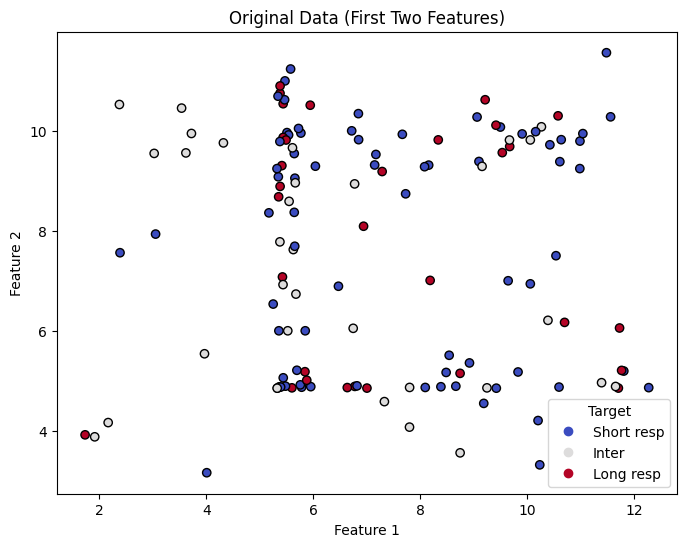

In [38]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data (First Two Features)")
class_names = ["Short resp", "Inter", "Long resp"]
plt.legend(handles=scatter.legend_elements()[0], labels=class_names, title="Target")
plt.show()


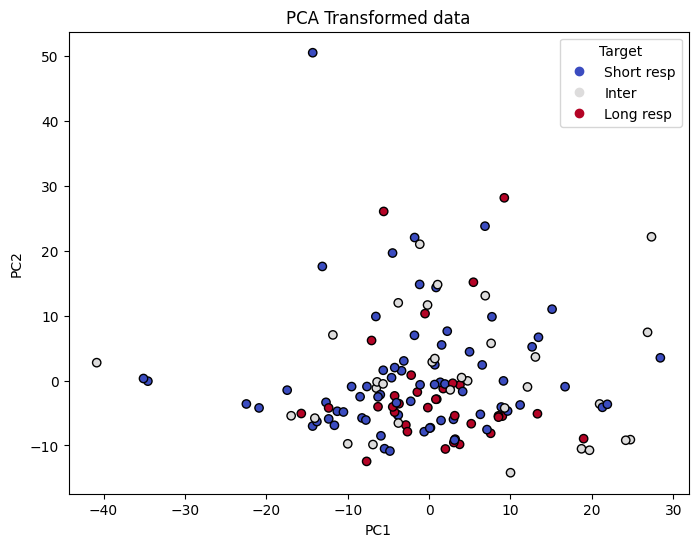

In [39]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Transformed data")
class_names = ["Short resp", "Inter", "Long resp"]
plt.legend(handles=scatter.legend_elements()[0], labels=class_names, title="Target")
plt.show()


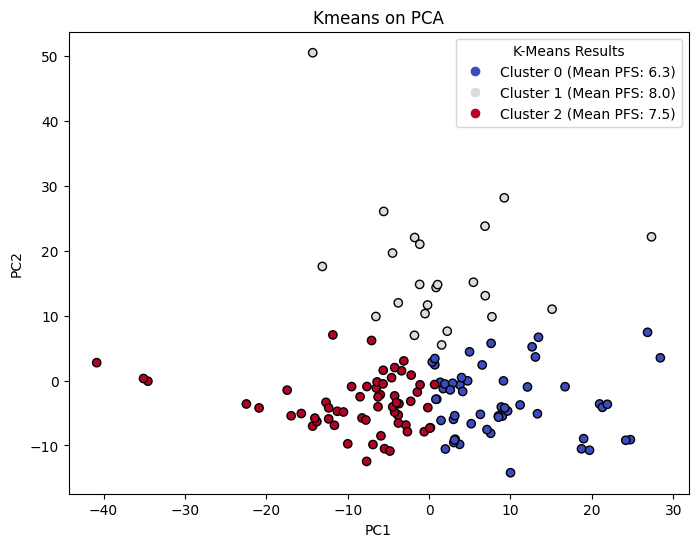

In [40]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42).fit(X_pca)
y_kmeans = kmeans.labels_

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='coolwarm', edgecolor='k')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Kmeans on PCA")
# Use the actual cluster numbers in the legend to stay objective
plt.legend(handles=scatter.legend_elements()[0], 
           labels=["Cluster 0 (Mean PFS: 6.3)", 
                   "Cluster 1 (Mean PFS: 8.0)", 
                   "Cluster 2 (Mean PFS: 7.5)"], 
           title="K-Means Results")
plt.show()

In [41]:
import polars as pl

results = pl.DataFrame({
    'Cluster': y_kmeans,
    'PFS_Month': clinical_gex['PFS_month'], # Removed .values
    'True_Label': y                         # Removed .values
})

with pl.Config(tbl_rows=-1):  # -1 means "all rows"
    # Sorting in Polars
    print(results.sort(['Cluster', 'PFS_Month']))

# Summary stats in Polars
cluster_summary = results.group_by('Cluster').agg([
    pl.col('PFS_Month').mean().alias('mean'),
    pl.col('PFS_Month').median().alias('median'),
    pl.col('PFS_Month').std().alias('std'),
    pl.len().alias('count')
])
print(cluster_summary)



shape: (137, 3)
┌─────────┬───────────┬────────────┐
│ Cluster ┆ PFS_Month ┆ True_Label │
│ ---     ┆ ---       ┆ ---        │
│ i32     ┆ f64       ┆ i64        │
╞═════════╪═══════════╪════════════╡
│ 0       ┆ 1.2       ┆ 0          │
│ 0       ┆ 1.3       ┆ 0          │
│ 0       ┆ 1.4       ┆ 0          │
│ 0       ┆ 1.4       ┆ 0          │
│ 0       ┆ 1.6       ┆ 0          │
│ 0       ┆ 1.8       ┆ 0          │
│ 0       ┆ 1.8       ┆ 0          │
│ 0       ┆ 1.9       ┆ 0          │
│ 0       ┆ 1.9       ┆ 0          │
│ 0       ┆ 2.1       ┆ 0          │
│ 0       ┆ 2.6       ┆ 0          │
│ 0       ┆ 2.8       ┆ 0          │
│ 0       ┆ 2.8       ┆ 0          │
│ 0       ┆ 2.9       ┆ 0          │
│ 0       ┆ 3.6       ┆ 0          │
│ 0       ┆ 3.6       ┆ 0          │
│ 0       ┆ 3.7       ┆ 0          │
│ 0       ┆ 3.7       ┆ 0          │
│ 0       ┆ 3.7       ┆ 0          │
│ 0       ┆ 3.9       ┆ 0          │
│ 0       ┆ 4.7       ┆ 0          │
│ 0       ┆ 5.4       

## 2. Missing Values

In [42]:
null_counts = clinical_gex.null_count()
null_clinical = {c: null_counts[c][0] for c in CLINICAL_COLS if null_counts[c][0] > 0}
null_gex_total = sum(null_counts[c][0] for c in GEX_COLS)

print("=== Missing values in clinical columns ===")
if null_clinical:
    for col, n in null_clinical.items():
        pct = n / len(clinical_gex) * 100
        print(f"  {col:35s}: {n:3d} ({pct:.1f}%)")
else:
    print("  None")

print(f"\n=== Missing values in GEX columns ===")
print(f"  Total missing cells: {null_gex_total}")

=== Missing values in clinical columns ===
  M_stage                            :  23 (16.8%)
  LDH                                :  29 (21.2%)
  brain_metastasis                   :  68 (49.6%)

=== Missing values in GEX columns ===
  Total missing cells: 0


## 3. Clinical Variables

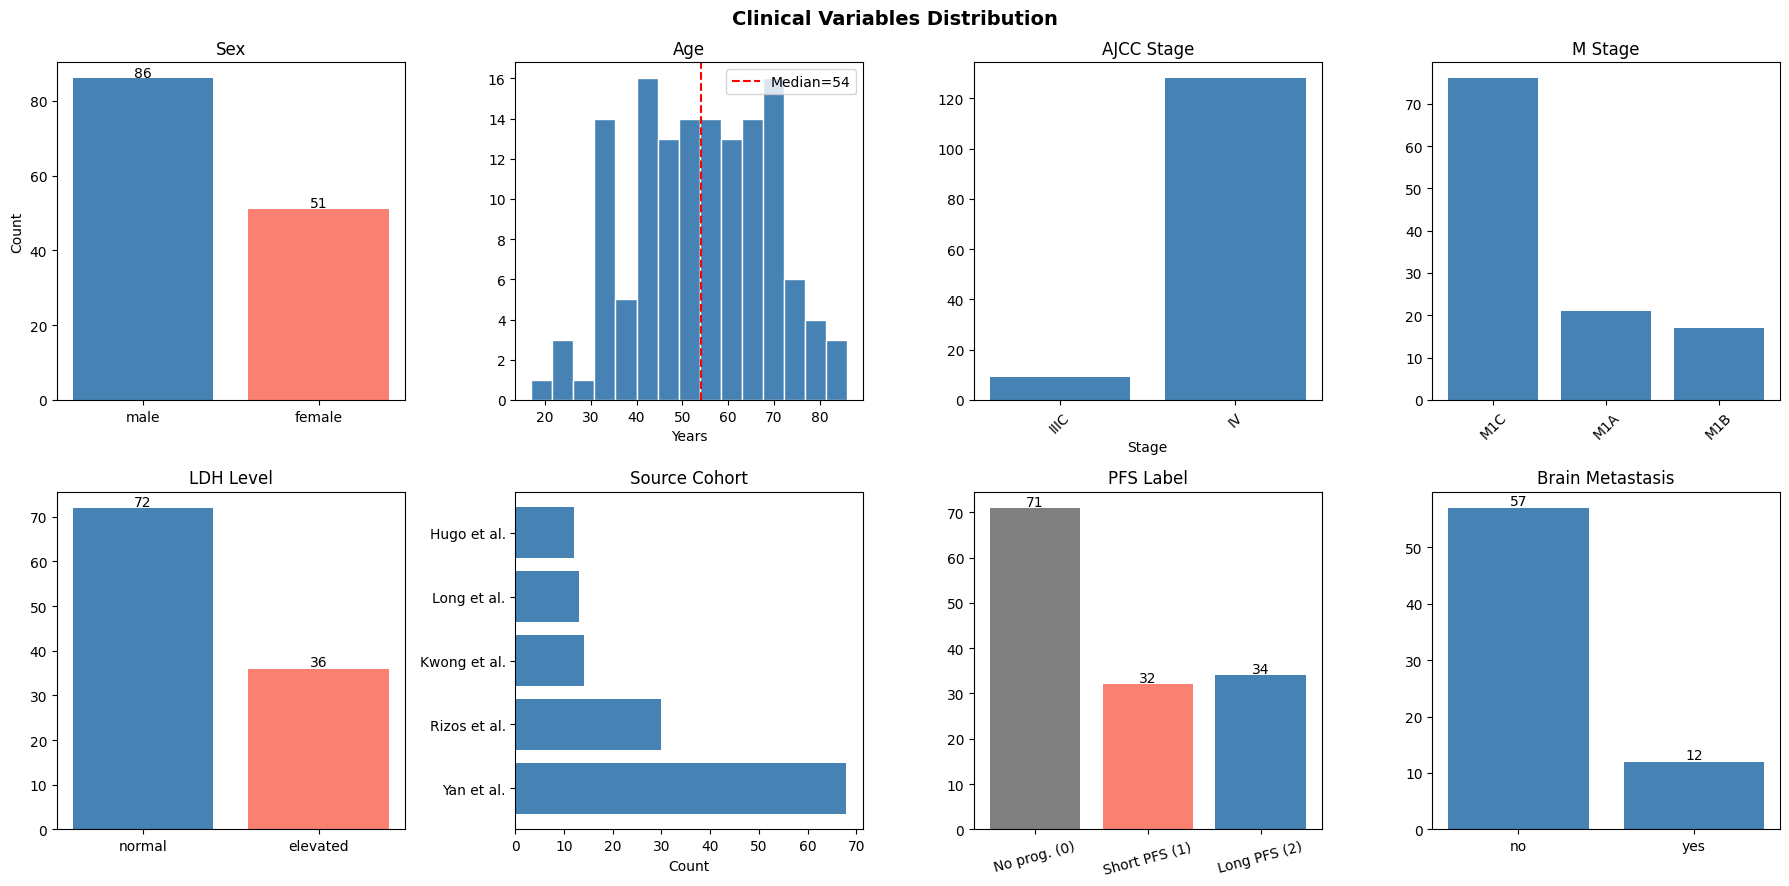

In [43]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Clinical Variables Distribution", fontsize=14, fontweight="bold")

df = clinical_gex.to_pandas()

# --- Sex ---
ax = axes[0, 0]
sex_counts = df["sex"].value_counts()
ax.bar(sex_counts.index, sex_counts.values, color=["steelblue", "salmon"])
ax.set_title("Sex")
ax.set_ylabel("Count")
for i, v in enumerate(sex_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")

# --- Age ---
ax = axes[0, 1]
ax.hist(df["age"].dropna(), bins=15, color="steelblue", edgecolor="white")
ax.axvline(df["age"].median(), color="red", linestyle="--", label=f"Median={df['age'].median():.0f}")
ax.set_title("Age")
ax.set_xlabel("Years")
ax.legend()

# --- AJCC Stage ---
ax = axes[0, 2]
stage_order = ["I", "II", "IIA", "IIB", "IIC", "III", "IIIA", "IIIB", "IIIC", "IV"]
stage_counts = df["AJCC_stage"].value_counts().reindex(
    [s for s in stage_order if s in df["AJCC_stage"].values], fill_value=0
)
ax.bar(stage_counts.index, stage_counts.values, color="steelblue")
ax.set_title("AJCC Stage")
ax.set_xlabel("Stage")
ax.tick_params(axis="x", rotation=45)

# --- M Stage ---
ax = axes[0, 3]
m_counts = df["M_stage"].value_counts()
ax.bar(m_counts.index, m_counts.values, color="steelblue")
ax.set_title("M Stage")
ax.tick_params(axis="x", rotation=45)

# --- LDH ---
ax = axes[1, 0]
ldh_counts = df["LDH"].value_counts()
ax.bar(ldh_counts.index, ldh_counts.values, color=["steelblue", "salmon", "gray"][:len(ldh_counts)])
ax.set_title("LDH Level")
for i, v in enumerate(ldh_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")

# --- Data source ---
ax = axes[1, 1]
src_counts = df["source"].value_counts()
ax.barh(src_counts.index, src_counts.values, color="steelblue")
ax.set_title("Source Cohort")
ax.set_xlabel("Count")

# --- PFS label ---
ax = axes[1, 2]
pfs_counts = df["pfs_label"].value_counts().sort_index()
labels = {0: "No prog. (0)", 1: "Short PFS (1)", 2: "Long PFS (2)"}
ax.bar([labels.get(i, str(i)) for i in pfs_counts.index], pfs_counts.values, color=["gray", "salmon", "steelblue"])
ax.set_title("PFS Label")
ax.tick_params(axis="x", rotation=15)
for i, v in enumerate(pfs_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")

# --- Brain metastasis ---
ax = axes[1, 3]
bm_counts = df["brain_metastasis"].value_counts()
ax.bar(bm_counts.index.astype(str), bm_counts.values, color="steelblue")
ax.set_title("Brain Metastasis")
for i, v in enumerate(bm_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")

plt.tight_layout()
plt.show()

## 4. Treatment & BRAF Mutations

/var/folders/cy/vstztct90b90zhd8ssbmwpgh0000gn/T/ipykernel_60631/1745848542.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


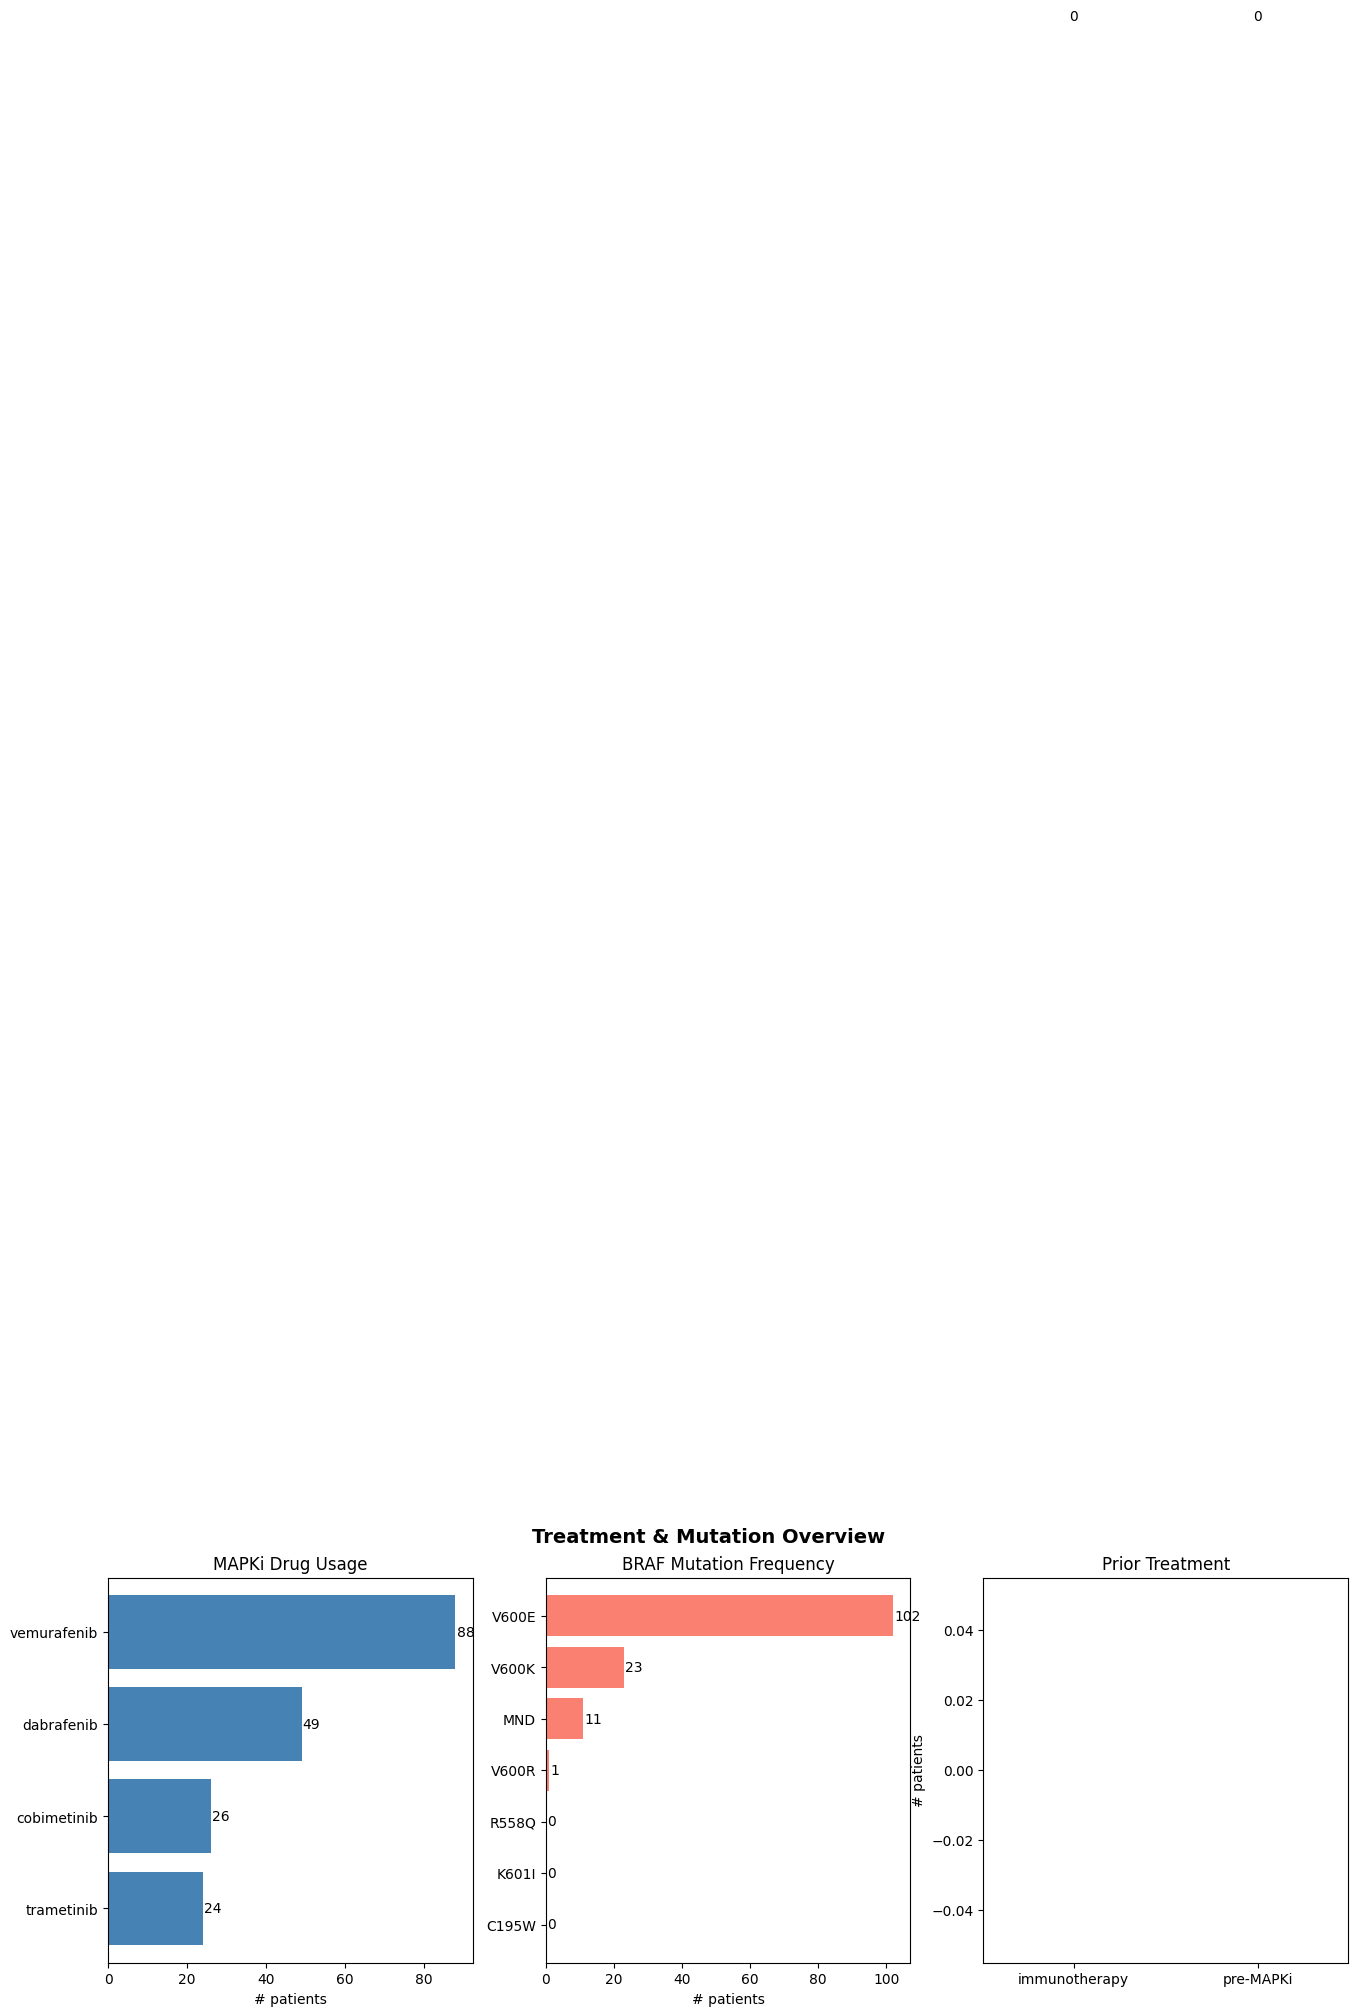

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Treatment & Mutation Overview", fontsize=14, fontweight="bold")

# --- MAPKi drugs (binary flags) ---
ax = axes[0]
drugs = ["cobimetinib", "dabrafenib", "trametinib", "vemurafenib"]
drug_counts = df[drugs].sum().sort_values(ascending=True)
ax.barh(drug_counts.index, drug_counts.values, color="steelblue")
ax.set_title("MAPKi Drug Usage")
ax.set_xlabel("# patients")
for i, v in enumerate(drug_counts.values):
    ax.text(v + 0.3, i, str(int(v)), va="center")

# --- BRAF mutations ---
ax = axes[1]
mutations = ["C195W", "K601I", "MND", "R558Q", "V600E", "V600K", "V600R"]
mut_counts = df[mutations].sum().sort_values(ascending=True)
ax.barh(mut_counts.index, mut_counts.values, color="salmon")
ax.set_title("BRAF Mutation Frequency")
ax.set_xlabel("# patients")
for i, v in enumerate(mut_counts.values):
    ax.text(v + 0.3, i, str(int(v)), va="center")

# --- Prior treatment flags ---
ax = axes[2]
prior = {"immunotherapy": df["immunotherapy_treatment"].eq("yes").sum(),
         "pre-MAPKi":     df["pre_MAPKi_treatment"].eq("yes").sum()}
ax.bar(list(prior.keys()), list(prior.values()), color=["steelblue", "salmon"])
ax.set_title("Prior Treatment")
ax.set_ylabel("# patients")
for i, v in enumerate(prior.values()):
    ax.text(i, v + 0.5, str(v), ha="center")

plt.tight_layout()
plt.show()

## 5. Gene Expression Distribution

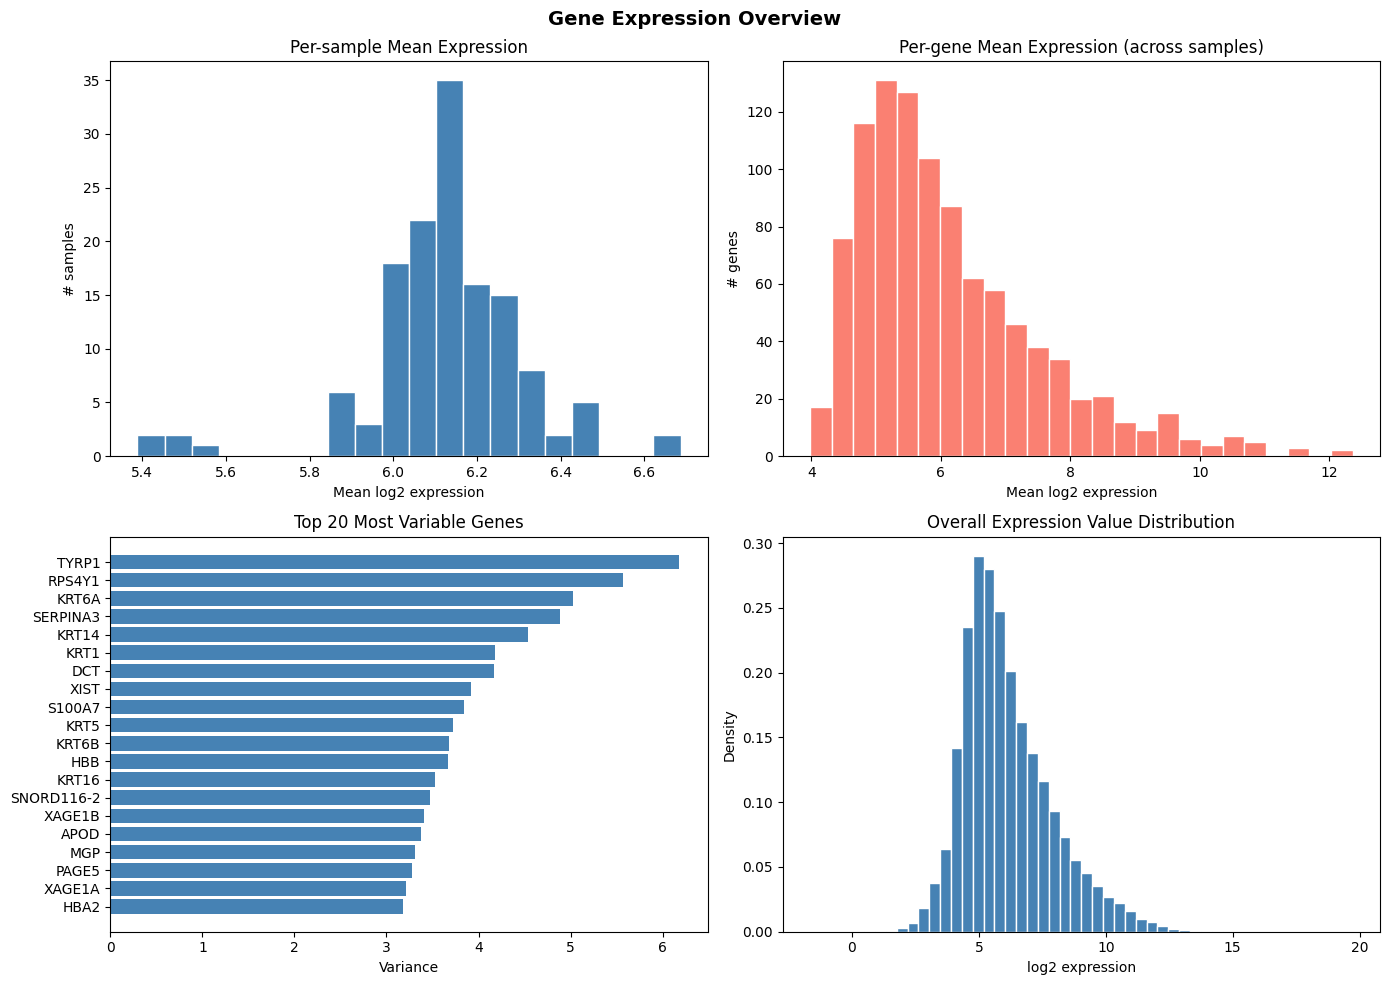


Expression range: [-1.660, 19.736]
Global mean: 6.121  |  std: 1.779


In [45]:
gex = df[GEX_COLS].values  # shape (137, 122)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Gene Expression Overview", fontsize=14, fontweight="bold")

# --- Per-sample mean expression ---
ax = axes[0, 0]
sample_means = gex.mean(axis=1)
ax.hist(sample_means, bins=20, color="steelblue", edgecolor="white")
ax.set_title("Per-sample Mean Expression")
ax.set_xlabel("Mean log2 expression")
ax.set_ylabel("# samples")

# --- Per-gene mean expression ---
ax = axes[0, 1]
gene_means = gex.mean(axis=0)
ax.hist(gene_means, bins=25, color="salmon", edgecolor="white")
ax.set_title("Per-gene Mean Expression (across samples)")
ax.set_xlabel("Mean log2 expression")
ax.set_ylabel("# genes")

# --- Per-gene variance (top 20 most variable genes) ---
ax = axes[1, 0]
gene_vars = gex.var(axis=0)
top20_idx = gene_vars.argsort()[::-1][:20]
top20_genes = [GEX_COLS[i] for i in top20_idx]
top20_vars  = gene_vars[top20_idx]
ax.barh(top20_genes[::-1], top20_vars[::-1], color="steelblue")
ax.set_title("Top 20 Most Variable Genes")
ax.set_xlabel("Variance")

# --- Overall expression value distribution ---
ax = axes[1, 1]
ax.hist(gex.ravel(), bins=50, color="steelblue", edgecolor="white", density=True)
ax.set_title("Overall Expression Value Distribution")
ax.set_xlabel("log2 expression")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

print(f"\nExpression range: [{gex.min():.3f}, {gex.max():.3f}]")
print(f"Global mean: {gex.mean():.3f}  |  std: {gex.std():.3f}")

## 6. Expression by PFS Label

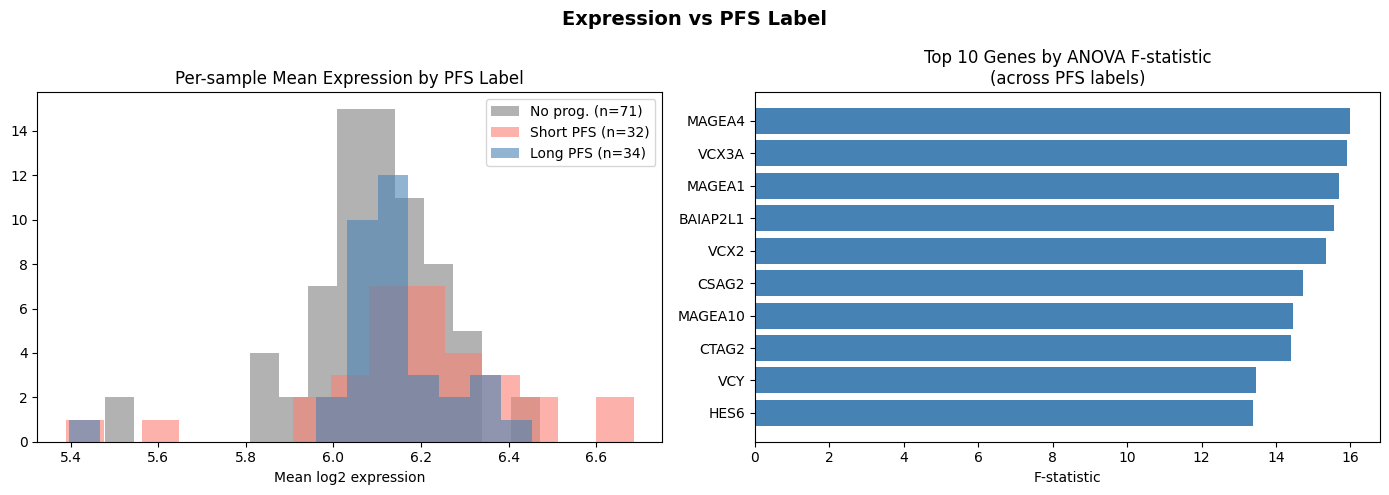

In [46]:
from scipy import stats

pfs_labels = df["pfs_label"].values
label_names = {0: "No prog.", 1: "Short PFS", 2: "Long PFS"}
colors = {0: "gray", 1: "salmon", 2: "steelblue"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Expression vs PFS Label", fontsize=14, fontweight="bold")

# --- Per-sample mean expression by PFS label ---
ax = axes[0]
for lbl in sorted(df["pfs_label"].unique()):
    mask = pfs_labels == lbl
    ax.hist(sample_means[mask], bins=15, alpha=0.6,
            label=f"{label_names[lbl]} (n={mask.sum()})", color=colors[lbl])
ax.set_title("Per-sample Mean Expression by PFS Label")
ax.set_xlabel("Mean log2 expression")
ax.legend()

# --- Top differentially expressed genes (ANOVA F-statistic) ---
ax = axes[1]
groups = [gex[pfs_labels == lbl] for lbl in sorted(df["pfs_label"].unique())]
f_stats = np.array([stats.f_oneway(*[g[:, i] for g in groups]).statistic for i in range(len(GEX_COLS))])
top10_idx = f_stats.argsort()[::-1][:10]
top10_genes = [GEX_COLS[i] for i in top10_idx]
top10_f = f_stats[top10_idx]
ax.barh(top10_genes[::-1], top10_f[::-1], color="steelblue")
ax.set_title("Top 10 Genes by ANOVA F-statistic\n(across PFS labels)")
ax.set_xlabel("F-statistic")

plt.tight_layout()
plt.show()